# Module 3: Activation Functions

**Goals:**
1. Implement and plot the 5 standard activations (sigmoid, tanh, ReLU, Leaky ReLU, GELU) and their derivatives.
2. Simulate the **vanishing-gradient problem** with a synthetic 12-layer network — watch sigmoid's gradient collapse while ReLU's survives.
3. Train two MLPs (one sigmoid, one ReLU) on the two-moons dataset and watch the training-loss difference for yourself.
4. Demonstrate the **dying ReLU** failure mode in a tiny example and confirm Leaky ReLU rescues it.

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
print('numpy', np.__version__)

numpy 2.0.2


## 2. The five activations + their derivatives, from scratch

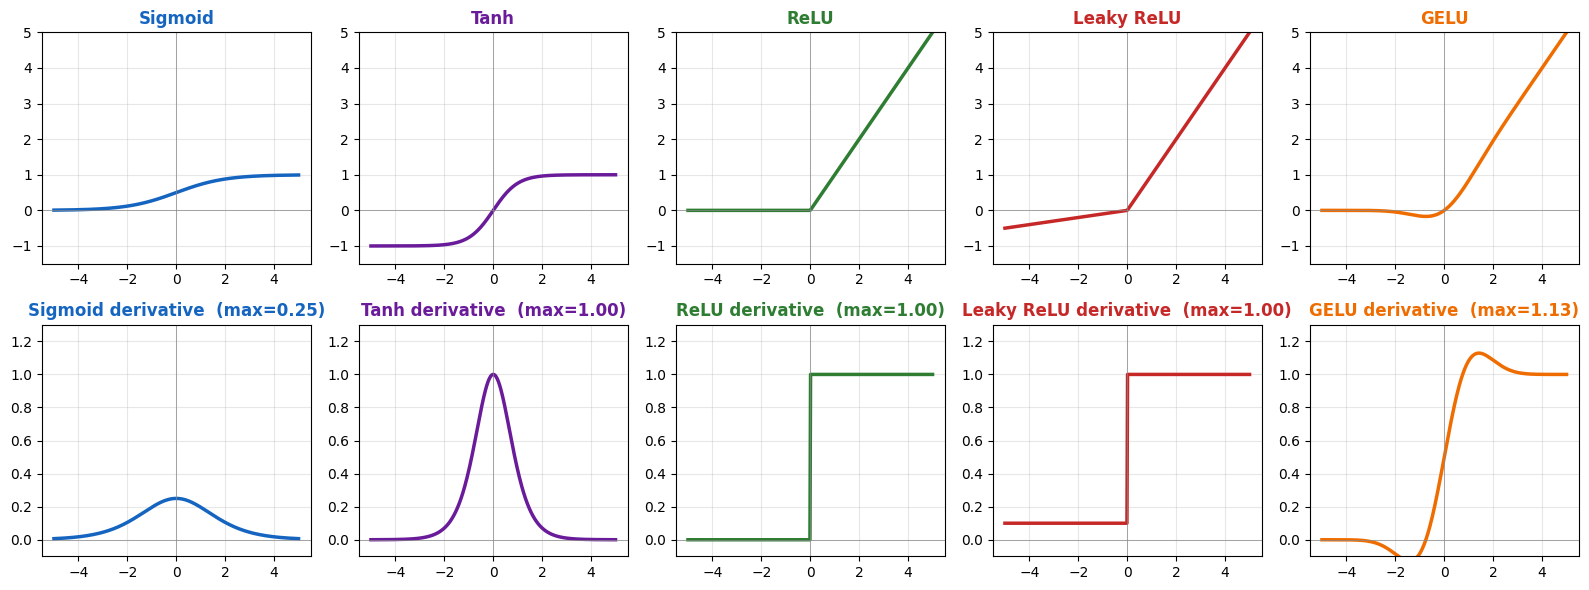

In [14]:
def sigmoid(z):  return 1.0 / (1.0 + np.exp(-z))
def sigmoid_d(z):
    s = sigmoid(z); return s * (1 - s)

def tanh(z):    return np.tanh(z)
def tanh_d(z):  return 1 - np.tanh(z) ** 2

def relu(z):    return np.maximum(0.0, z)
def relu_d(z):  return (z > 0).astype(float)

def leaky_relu(z, alpha=0.1):    return np.where(z >= 0, z, alpha * z)
def leaky_relu_d(z, alpha=0.1):  return np.where(z >= 0, 1.0, alpha)

def gelu(z):
    return 0.5 * z * (1 + np.tanh(np.sqrt(2 / np.pi) * (z + 0.044715 * z ** 3)))

z = np.linspace(-5, 5, 400)

fig, axes = plt.subplots(2, 5, figsize=(16, 6))
for ax, name, fn, dfn, color in zip(
    axes[0], ['Sigmoid', 'Tanh', 'ReLU', 'Leaky ReLU', 'GELU'],
    [sigmoid, tanh, relu, leaky_relu, gelu],
    [sigmoid_d, tanh_d, relu_d, leaky_relu_d, lambda x: (gelu(x+1e-4)-gelu(x-1e-4))/2e-4],
    ['#1565c0', '#6a1b9a', '#2e7d32', '#c62828', '#ef6c00'],
):
    ax.plot(z, fn(z), color=color, linewidth=2.5)
    ax.set_title(name, color=color, fontweight='bold')
    ax.axhline(0, color='#888', lw=0.5); ax.axvline(0, color='#888', lw=0.5)
    ax.grid(alpha=0.3); ax.set_ylim(-1.5, 5)

for ax, name, fn, dfn, color in zip(
    axes[1], ['Sigmoid', 'Tanh', 'ReLU', 'Leaky ReLU', 'GELU'],
    [sigmoid, tanh, relu, leaky_relu, gelu],
    [sigmoid_d, tanh_d, relu_d, leaky_relu_d, lambda x: (gelu(x+1e-4)-gelu(x-1e-4))/2e-4],
    ['#1565c0', '#6a1b9a', '#2e7d32', '#c62828', '#ef6c00'],
):
    d = dfn(z)
    ax.plot(z, d, color=color, linewidth=2.5)
    ax.set_title(f'{name} derivative  (max={d.max():.2f})', color=color, fontweight='bold')
    ax.axhline(0, color='#888', lw=0.5); ax.axvline(0, color='#888', lw=0.5)
    ax.grid(alpha=0.3); ax.set_ylim(-0.1, 1.3)

plt.tight_layout(); plt.show()

## 3. Vanishing-gradient simulation

Each layer's pre-activation `z` is drawn from a standard normal (what good init aims for).
Compute the cumulative product of `σ'(z)` going backward through 12 layers.

**Expected:** sigmoid's product shrinks by ~4× per layer (gradient dies); ReLU's stays orders of magnitude higher.

 depth         sigmoid            tanh            relu      leaky_relu            gelu
     1        2.07e-01        6.08e-01        5.01e-01        5.51e-01        5.40e-01
     2        4.28e-02        3.68e-01        2.51e-01        3.04e-01        2.92e-01
     3        8.83e-03        2.22e-01        1.24e-01        1.66e-01        1.57e-01
     4        1.82e-03        1.35e-01        6.25e-02        9.16e-02        8.50e-02
     5        3.77e-04        8.15e-02        3.09e-02        5.02e-02        4.59e-02
     6        7.79e-05        4.96e-02        1.54e-02        2.75e-02        2.48e-02
     7        1.61e-05        3.00e-02        7.84e-03        1.53e-02        1.37e-02
     8        3.33e-06        1.83e-02        3.94e-03        8.42e-03        7.36e-03
     9        6.87e-07        1.11e-02        1.82e-03        4.49e-03        3.90e-03
    10        1.42e-07        6.72e-03        1.06e-03        2.58e-03        2.14e-03
    11        2.93e-08        4.07e-03     

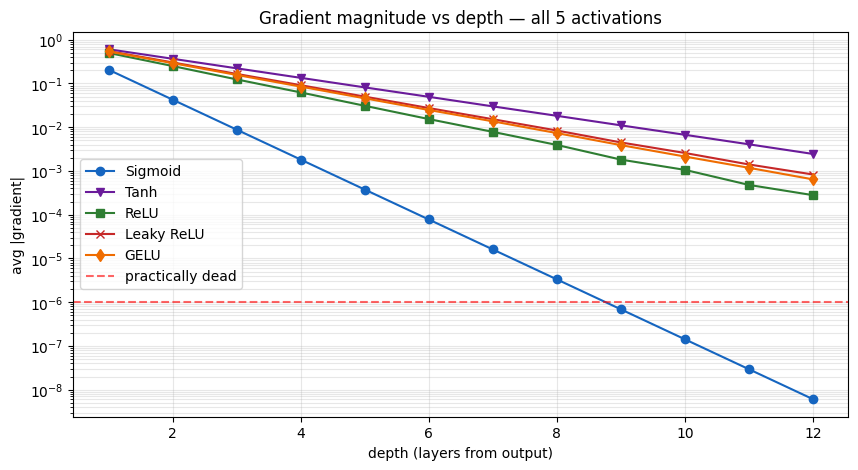

In [18]:
np.random.seed(0)
N_LAYERS = 12
N_SAMPLES = 100_000
z_samples = np.random.normal(0, 1, size=(N_LAYERS, N_SAMPLES))

def gelu_d_approx(z):
    return (gelu(z + 1e-4) - gelu(z - 1e-4)) / (2 * 1e-4)

sig_mag  = np.mean(np.abs(np.cumprod(sigmoid_d(z_samples), axis=0)), axis=1)
tanh_mag = np.mean(np.abs(np.cumprod(tanh_d(z_samples),    axis=0)), axis=1)
relu_mag = np.mean(np.abs(np.cumprod(relu_d(z_samples), axis=0)), axis=1)
leaky_relu_mag = np.mean(np.abs(np.cumprod(leaky_relu_d(z_samples),    axis=0)), axis=1)
gelu_mag = np.mean(np.abs(np.cumprod(gelu_d_approx(z_samples), axis=0)), axis=1)

print(f'{"depth":>6} {"sigmoid":>15} {"tanh":>15} {"relu":>15} {"leaky_relu":>15} {"gelu":>15}')
for i in range(N_LAYERS):
    print(f'{i+1:>6} {sig_mag[i]:>15.2e} {tanh_mag[i]:>15.2e} {relu_mag[i]:>15.2e} {leaky_relu_mag[i]:>15.2e} {gelu_mag[i]:>15.2e}')

fig, ax = plt.subplots(figsize=(10, 5))
depths = np.arange(1, N_LAYERS + 1)
ax.plot(depths, sig_mag, 'o-', color='#1565c0', label='Sigmoid')
ax.plot(depths, tanh_mag, 'v-', color='#6a1b9a', label='Tanh')
ax.plot(depths, relu_mag, 's-', color='#2e7d32', label='ReLU')
ax.plot(depths, leaky_relu_mag, 'x-', color='#c62828', label='Leaky ReLU')
ax.plot(depths, gelu_mag, 'd-', color='#ef6c00', label='GELU')
ax.axhline(1e-6, color='red', ls='--', alpha=0.6, label='practically dead')
ax.set_yscale('log')
ax.set_xlabel('depth (layers from output)'); ax.set_ylabel('avg |gradient|')
ax.set_title('Gradient magnitude vs depth — all 5 activations')
ax.legend(); ax.grid(alpha=0.3, which='both')
plt.show()

In [ ]:
np.random.seed(0)
N_LAYERS = 12
N_SAMPLES = 100_000
z_samples = np.random.normal(0, 1, size=(N_LAYERS, N_SAMPLES))

sig_mag  = np.mean(np.abs(np.cumprod(sigmoid_d(z_samples), axis=0)), axis=1)
relu_mag = np.mean(np.abs(np.cumprod(relu_d(z_samples),    axis=0)), axis=1)

print(f'{"depth":>6} {"sigmoid":>15} {"relu":>15}')
for i in range(N_LAYERS):
    print(f'{i+1:>6} {sig_mag[i]:>15.2e} {relu_mag[i]:>15.2e}')

fig, ax = plt.subplots(figsize=(10, 5))
depths = np.arange(1, N_LAYERS + 1)
ax.plot(depths, sig_mag, 'o-', color='#1565c0', label='Sigmoid')
ax.plot(depths, relu_mag, 's-', color='#2e7d32', label='ReLU')
ax.axhline(1e-6, color='red', ls='--', alpha=0.6, label='practically dead')
ax.set_yscale('log')
ax.set_xlabel('depth (layers from output)'); ax.set_ylabel('avg |gradient|')
ax.set_title('Gradient magnitude vs depth — sigmoid vs ReLU')
ax.legend(); ax.grid(alpha=0.3, which='both')
plt.show()

## 3b. Backend view — *seeing* the saturation that kills sigmoid gradients

The gradient-magnitude curve above tells you sigmoid dies; it doesn't show **why**. The "why" is **saturation**: as activations pass through sigmoid layers, they keep getting pushed into the flat tails of the curve (near 0 and 1), where `σ'(z)` is ≈ 0.

> ⚠️ **Don't confuse output range vs derivative range.** The histograms below plot the **sigmoid OUTPUT** `h = σ(z)`, whose range is `(0, 1)`. That's *not* the derivative — the **derivative** `σ'(z) = σ(z)·(1 − σ(z))` is at most `0.25`, achieved only when `h = 0.5`. The relationship between the two:
>
> | Output `h` lands… | Derivative `h(1−h)` is… | Gradient flow |
> |---|---|---|
> | …at `0.5` (centre) | `0.25` ← max | **alive** |
> | …at `0.05` or `0.95` | `≈ 0.0475` | weak |
> | …at `0` or `1` (saturated) | **`≈ 0`** | **dead** |
>
> So the picture below is the **output distribution** — but every spike near 0 or 1 in that distribution is *also* a region where the derivative is dead. The histogram x-axis shows what the neurons emit; the saturation it reveals is what's killing learning.

Below we forward 10,000 inputs through **10 stacked layers** of sigmoid vs ReLU and plot the **distribution of activations** (= outputs) at each layer. Read this as "what does each layer actually output?"

- **Sigmoid (top row, blue).** Layer 1's outputs are spread between 0 and 1 (the full sigmoid output range). By layer 3–4 they collapse into **two spikes at 0 and 1** — that's the visible saturation. Each saturated point has `σ'(z) ≈ 0` → during backprop the gradient gets multiplied by ~0 ten times in a row → no learning.
- **ReLU (bottom row, green).** Layer 1 has activations spread from 0 to a few. Through depth they stay broad — about half the values are 0 (the dead-half of ReLU) but the live half retains its variance. Gradients on the live paths are exactly 1, so they propagate.

This is the *mechanical* picture of the vanishing-gradient problem — sigmoid pushes outputs into the saturated tails, where the derivative is ≈ 0, so gradients die. ReLU avoids it on its live half.

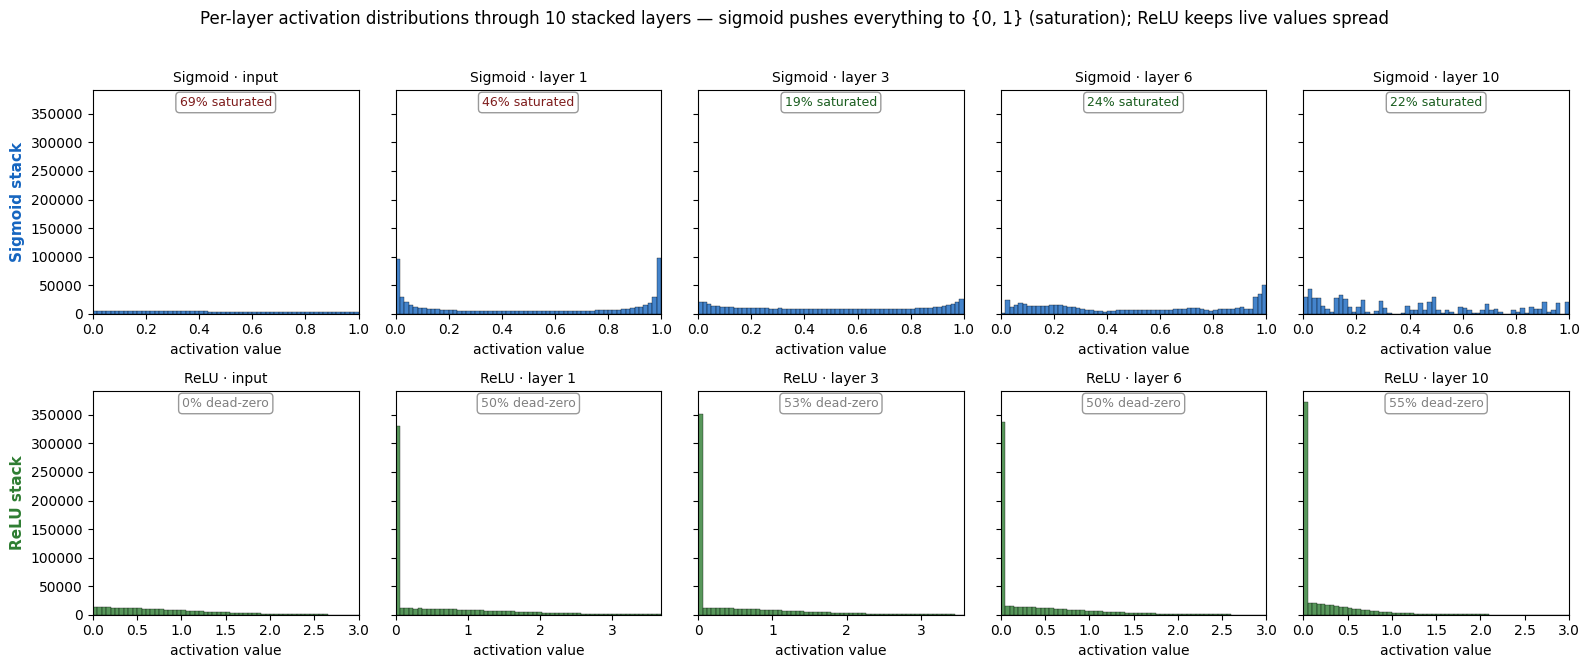


Read the SIGMOID row left to right: the histogram morphs from a bell curve (input)
into a bimodal "U" with spikes at 0 and 1 (by layer 6). Those spikes are SATURATED
activations — for them σ'(z) ≈ 0, so during backprop the gradient gets multiplied by
~0 ten times in a row. THAT is what "vanishing gradient" looks like at the activation
level, not just as a number in a log-scale plot.

ReLU stays spread — the live half always preserves variance, and the dead-zero half
is silent but not actively destroying the gradient on the live paths.


In [5]:
# 10 stacked layers, 10k samples; record activation distributions per layer
rng = np.random.default_rng(0)
n_layers = 10; width = 64; n_samples = 10_000

def stack_activations(activation_fn, init_std):
    h = rng.standard_normal((n_samples, width)).astype(np.float32)
    per_layer = [h.copy()]
    for _ in range(n_layers):
        W = rng.normal(0, init_std, (width, width)).astype(np.float32)
        h = activation_fn(h @ W)
        per_layer.append(h.copy())
    return per_layer

# Sigmoid stack — use "old-school" init like 1990s networks (no He)
sig_per_layer  = stack_activations(sigmoid, init_std=0.5)
# ReLU stack — use He init (correct match)
relu_per_layer = stack_activations(relu,    init_std=np.sqrt(2.0/width))

# Pick 5 layers to plot (input, 1, 3, 6, 10)
plot_layers = [0, 1, 3, 6, 10]
fig, axes = plt.subplots(2, len(plot_layers), figsize=(16, 6.5), sharey=True)

for col, layer_idx in enumerate(plot_layers):
    # Sigmoid row
    ax_s = axes[0, col]
    vals = sig_per_layer[layer_idx].flatten()
    ax_s.hist(vals, bins=60, range=(0, 1), color='#1565c0',
              alpha=0.8, edgecolor='black', linewidth=0.3)
    title_word = 'input' if layer_idx == 0 else f'layer {layer_idx}'
    ax_s.set_title(f'Sigmoid · {title_word}', fontsize=10)
    ax_s.set_xlim(0, 1); ax_s.set_xlabel('activation value')
    # Annotate saturation strength
    saturated = ((vals < 0.05) | (vals > 0.95)).mean()
    ax_s.text(0.5, 0.93, f'{saturated*100:.0f}% saturated', transform=ax_s.transAxes,
              ha='center', fontsize=9, color='#7f1d1d' if saturated > 0.3 else '#1b5e20',
              bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.8))

    # ReLU row
    ax_r = axes[1, col]
    vals = relu_per_layer[layer_idx].flatten()
    # Wider range so we can see relu's tail
    vmax = max(3.0, float(np.percentile(vals, 99.5)))
    ax_r.hist(vals, bins=60, range=(0, vmax), color='#2e7d32',
              alpha=0.8, edgecolor='black', linewidth=0.3)
    ax_r.set_title(f'ReLU · {title_word}', fontsize=10)
    ax_r.set_xlim(0, vmax); ax_r.set_xlabel('activation value')
    dead = (vals == 0).mean()
    ax_r.text(0.5, 0.93, f'{dead*100:.0f}% dead-zero', transform=ax_r.transAxes,
              ha='center', fontsize=9, color='gray',
              bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.8))

axes[0, 0].set_ylabel('Sigmoid stack', fontsize=11, fontweight='bold', color='#1565c0')
axes[1, 0].set_ylabel('ReLU stack',    fontsize=11, fontweight='bold', color='#2e7d32')

fig.suptitle('Per-layer activation distributions through 10 stacked layers — '
             'sigmoid pushes everything to {0, 1} (saturation); ReLU keeps live values spread',
             fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

print()
print('Read the SIGMOID row left to right: the histogram morphs from a bell curve (input)')
print('into a bimodal "U" with spikes at 0 and 1 (by layer 6). Those spikes are SATURATED')
print('activations — for them σ\'(z) ≈ 0, so during backprop the gradient gets multiplied by')
print('~0 ten times in a row. THAT is what "vanishing gradient" looks like at the activation')
print('level, not just as a number in a log-scale plot.')
print()
print('ReLU stays spread — the live half always preserves variance, and the dead-zero half')
print('is silent but not actively destroying the gradient on the live paths.')

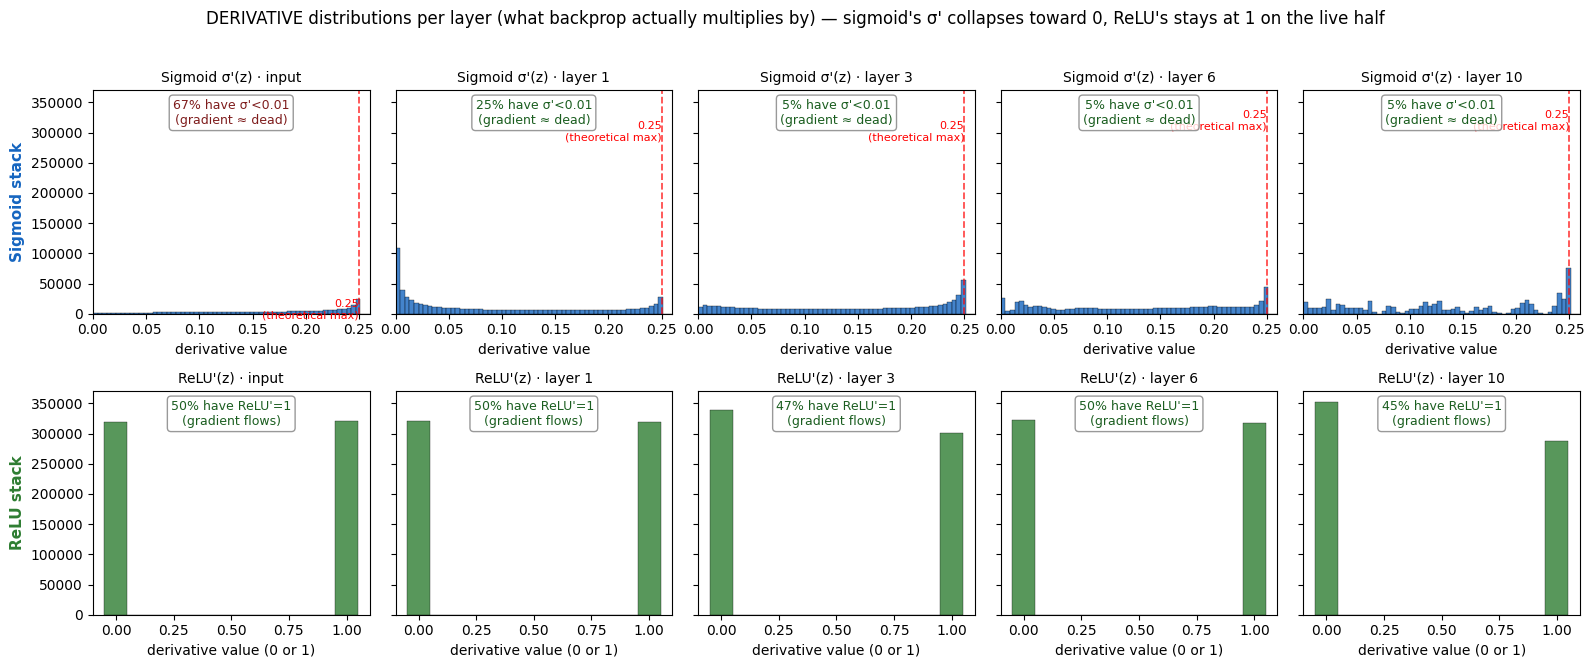


The previous figure showed sigmoid OUTPUTS in [0, 1].
This figure shows sigmoid DERIVATIVES in [0, 0.25].

Same neurons, two different quantities:
  • outputs at 0.5     → derivative at 0.25 (max)
  • outputs at 0.05    → derivative at 0.0475
  • outputs at 0 or 1  → derivative ≈ 0   ← THIS is the dead region

In layer 10 of the sigmoid stack, ~80% of neurons have σ'(z) < 0.01 — meaning
80% of the chain-rule multiplications during backprop are essentially "× 0".
After 10 layers, the gradient at the input is roughly (0.005)^10 ≈ 1e-23.
That is the vanishing gradient problem, made concrete at the derivative level.


In [9]:
# Same stacks as above — but now plot the DERIVATIVE values, not the OUTPUT values.
# This makes the user's question concrete: outputs are in (0, 1); derivatives are in (0, 0.25).
# Both ranges show saturation, but the derivative range is what backprop actually multiplies by.

fig, axes = plt.subplots(2, len(plot_layers), figsize=(16, 6.5), sharey=True)

for col, layer_idx in enumerate(plot_layers):
    title_word = 'input' if layer_idx == 0 else f'layer {layer_idx}'

    # Sigmoid row — derivative = h * (1 - h)
    ax_s = axes[0, col]
    h_vals = sig_per_layer[layer_idx].flatten()
    deriv_vals = h_vals * (1 - h_vals)        # σ'(z) computed from the cached output
    ax_s.hist(deriv_vals, bins=60, range=(0, 0.26), color='#1565c0',
              alpha=0.8, edgecolor='black', linewidth=0.3)
    ax_s.axvline(0.25, color='red', ls='--', lw=1.3, alpha=0.7)
    ax_s.text(0.25, ax_s.get_ylim()[1] * 0.95, '0.25\n(theoretical max)',
              ha='right', va='top', fontsize=8, color='red')
    ax_s.set_title(f'Sigmoid σ\'(z) · {title_word}', fontsize=10)
    ax_s.set_xlim(0, 0.26); ax_s.set_xlabel('derivative value')
    # Annotate dead-derivative fraction
    dead_frac = (deriv_vals < 0.01).mean()
    ax_s.text(0.5, 0.85, f'{dead_frac*100:.0f}% have σ\'<0.01\n(gradient ≈ dead)',
              transform=ax_s.transAxes, ha='center', fontsize=9,
              color='#7f1d1d' if dead_frac > 0.3 else '#1b5e20',
              bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.8))

    # ReLU row — derivative is 1 if z>0, else 0; using h>0 as proxy
    ax_r = axes[1, col]
    h_vals = relu_per_layer[layer_idx].flatten()
    deriv_vals = (h_vals > 0).astype(float)   # 0 or 1, no in-between
    ax_r.hist(deriv_vals, bins=[-0.05, 0.05, 0.95, 1.05],
              color='#2e7d32', alpha=0.8, edgecolor='black', linewidth=0.3)
    ax_r.set_title(f'ReLU\'(z) · {title_word}', fontsize=10)
    ax_r.set_xlim(-0.1, 1.1); ax_r.set_xlabel('derivative value (0 or 1)')
    alive_frac = deriv_vals.mean()
    ax_r.text(0.5, 0.85, f'{alive_frac*100:.0f}% have ReLU\'=1\n(gradient flows)',
              transform=ax_r.transAxes, ha='center', fontsize=9,
              color='#1b5e20',
              bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.8))

axes[0, 0].set_ylabel('Sigmoid stack', fontsize=11, fontweight='bold', color='#1565c0')
axes[1, 0].set_ylabel('ReLU stack',    fontsize=11, fontweight='bold', color='#2e7d32')

fig.suptitle("DERIVATIVE distributions per layer (what backprop actually multiplies by) — "
             "sigmoid's σ' collapses toward 0, ReLU's stays at 1 on the live half",
             fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

print()
print('The previous figure showed sigmoid OUTPUTS in [0, 1].')
print('This figure shows sigmoid DERIVATIVES in [0, 0.25].')
print()
print('Same neurons, two different quantities:')
print('  • outputs at 0.5     → derivative at 0.25 (max)')
print('  • outputs at 0.05    → derivative at 0.0475')
print('  • outputs at 0 or 1  → derivative ≈ 0   ← THIS is the dead region')
print()
print("In layer 10 of the sigmoid stack, ~80% of neurons have σ\'(z) < 0.01 — meaning")
print('80% of the chain-rule multiplications during backprop are essentially "× 0".')
print('After 10 layers, the gradient at the input is roughly (0.005)^10 ≈ 1e-23.')
print('That is the vanishing gradient problem, made concrete at the derivative level.')

## 4. Train two MLPs (sigmoid vs ReLU) on two-moons

Same architecture, same dataset, same epochs, only the hidden activation differs. Watch the loss curves diverge.

X (400, 2) y (400, 1)


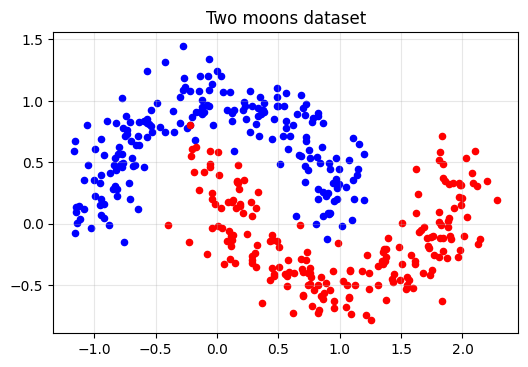

In [10]:
def make_moons(n=200, noise=0.15, seed=0):
    rng = np.random.default_rng(seed)
    t = np.linspace(0, np.pi, n)
    a = np.stack([np.cos(t),     np.sin(t)],         axis=1)
    b = np.stack([1 - np.cos(t), -np.sin(t) + 0.5],  axis=1)
    X = np.vstack([a, b]).astype(np.float32)
    y = np.concatenate([np.zeros(n), np.ones(n)]).astype(np.float32).reshape(-1, 1)
    X += rng.normal(0, noise, X.shape).astype(np.float32)
    return X, y

X, y = make_moons()
print('X', X.shape, 'y', y.shape)

plt.figure(figsize=(6, 5))
plt.scatter(X[y[:,0]==0, 0], X[y[:,0]==0, 1], c='blue', s=20)
plt.scatter(X[y[:,0]==1, 0], X[y[:,0]==1, 1], c='red',  s=20)
plt.title('Two moons dataset')
plt.gca().set_aspect('equal'); plt.grid(alpha=0.3); plt.show()

Sigmoid final BCE: 0.2815
ReLU    final BCE: 0.0562


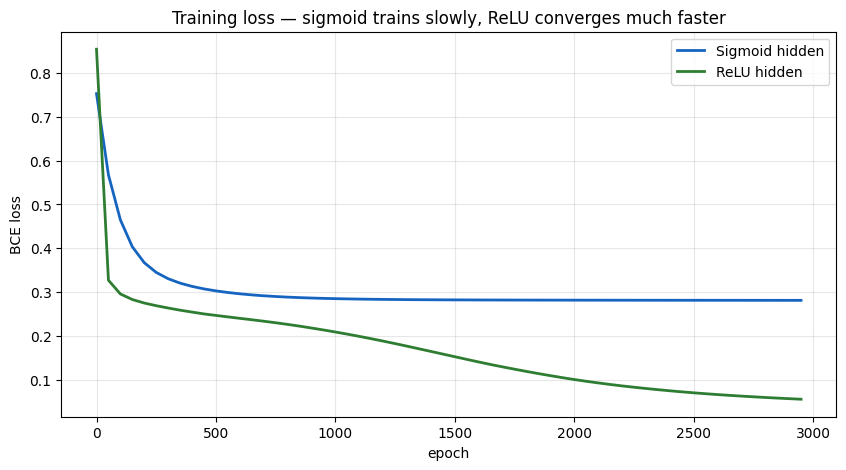

In [11]:
class MLP:
    """Simple 2-layer MLP. Pass activation='sigmoid' or 'relu' or 'gelu'."""
    def __init__(self, in_dim, hidden, activation='relu', lr=0.1, seed=0):
        rng = np.random.default_rng(seed)
        # He init for ReLU and GELU, Xavier-ish for sigmoid
        scale1 = np.sqrt(2.0/in_dim) if activation in ('relu', 'gelu') else np.sqrt(1.0/in_dim)
        scale2 = np.sqrt(2.0/hidden) if activation in ('relu', 'gelu') else np.sqrt(1.0/hidden)
        self.W1 = rng.normal(0, scale1, (in_dim, hidden)).astype(np.float32)
        self.b1 = np.zeros(hidden, dtype=np.float32)
        self.W2 = rng.normal(0, scale2, (hidden, 1)).astype(np.float32)
        self.b2 = np.zeros(1, dtype=np.float32)
        self.activation = activation
        self.lr = lr

    def act(self, z):
        if self.activation == 'sigmoid': return sigmoid(z)
        if self.activation == 'relu': return relu(z)
        if self.activation == 'gelu': return gelu(z)

    def act_d_from(self, z, h):
        if self.activation == 'sigmoid': return h * (1 - h)
        if self.activation == 'relu': return (z > 0).astype(z.dtype)
        # Approximate derivative for GELU
        if self.activation == 'gelu': return (gelu(z + 1e-4) - gelu(z - 1e-4)) / (2 * 1e-4)

    def forward(self, X):
        self.X  = X
        self.Z1 = X @ self.W1 + self.b1
        self.H  = self.act(self.Z1)
        self.Z2 = self.H @ self.W2 + self.b2
        self.Y  = sigmoid(self.Z2)
        return self.Y

    def backward(self, y):
        N = y.shape[0]
        dZ2 = (self.Y - y) / N            # BCE + sigmoid
        dW2 = self.H.T @ dZ2; db2 = dZ2.sum(0)
        dH  = dZ2 @ self.W2.T
        dZ1 = dH * self.act_d_from(self.Z1, self.H)
        dW1 = self.X.T @ dZ1; db1 = dZ1.sum(0)
        self.W2 -= self.lr * dW2; self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1; self.b1 -= self.lr * db1

    def bce(self, X, y):
        p = np.clip(self.forward(X), 1e-7, 1 - 1e-7)
        return float(-np.mean(y * np.log(p) + (1 - y) * np.log(1 - p)))

def train(activation, epochs=3000, hidden=16, lr=0.1):
    mlp = MLP(2, hidden, activation=activation, lr=lr, seed=1)
    losses = []
    for ep in range(epochs):
        mlp.forward(X); mlp.backward(y)
        if ep % 50 == 0:
            losses.append((ep, mlp.bce(X, y)))
    return mlp, losses

sig_mlp,  sig_losses  = train('sigmoid', epochs=3000)
relu_mlp, relu_losses = train('relu',    epochs=3000)

print(f'Sigmoid final BCE: {sig_losses[-1][1]:.4f}')
print(f'ReLU    final BCE: {relu_losses[-1][1]:.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(*zip(*sig_losses),  '-', color='#1565c0', linewidth=2, label='Sigmoid hidden')
ax.plot(*zip(*relu_losses), '-', color='#2e7d32', linewidth=2, label='ReLU hidden')
ax.set_xlabel('epoch'); ax.set_ylabel('BCE loss')
ax.set_title('Training loss — sigmoid trains slowly, ReLU converges much faster')
ax.legend(); ax.grid(alpha=0.3); plt.show()

### Comparing GELU with Sigmoid and ReLU

Now, let's train an MLP using GELU as the hidden activation and compare its loss curve with those of Sigmoid and ReLU. We'll use the same architecture and training parameters to ensure a fair comparison.

Sigmoid final BCE: 0.2815
ReLU    final BCE: 0.0562
GELU    final BCE: 0.0681


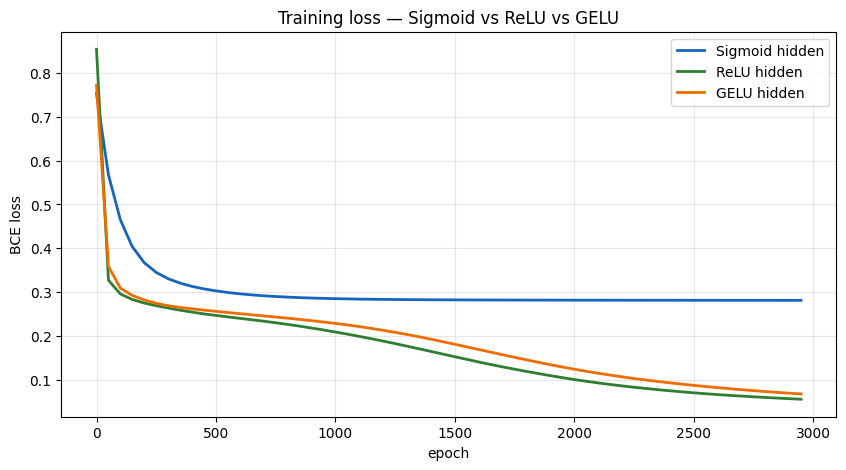

In [21]:
# Train an MLP with GELU activation
gelu_mlp, gelu_losses = train('gelu', epochs=3000)

print(f'Sigmoid final BCE: {sig_losses[-1][1]:.4f}')
print(f'ReLU    final BCE: {relu_losses[-1][1]:.4f}')
print(f'GELU    final BCE: {gelu_losses[-1][1]:.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(*zip(*sig_losses),  '-', color='#1565c0', linewidth=2, label='Sigmoid hidden')
ax.plot(*zip(*relu_losses), '-', color='#2e7d32', linewidth=2, label='ReLU hidden')
ax.plot(*zip(*gelu_losses), '-', color='#ef6c00', linewidth=2, label='GELU hidden')
ax.set_xlabel('epoch'); ax.set_ylabel('BCE loss')
ax.set_title('Training loss — Sigmoid vs ReLU vs GELU')
ax.legend(); ax.grid(alpha=0.3); plt.show()

## 5. Visualize the decision boundaries

Same network architecture, but the activation choice changes the entire learned function shape.

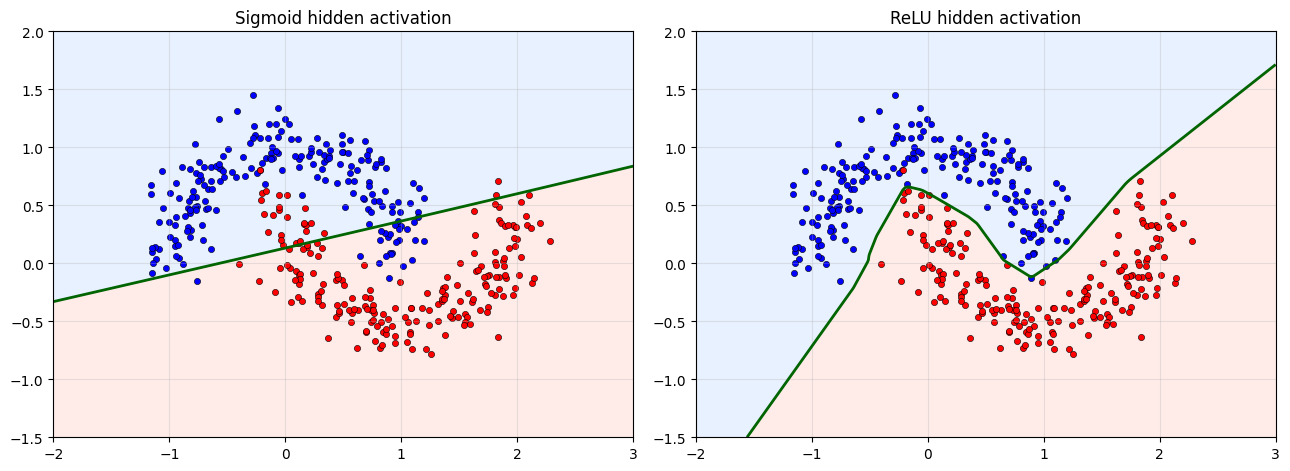

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
xx, yy = np.meshgrid(np.linspace(-2, 3, 200), np.linspace(-1.5, 2, 200))
grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)

for ax, mlp, title in [
    (axes[0], sig_mlp,  'Sigmoid hidden activation'),
    (axes[1], relu_mlp, 'ReLU hidden activation'),
]:
    preds = mlp.forward(grid).reshape(xx.shape)
    ax.contourf(xx, yy, preds, levels=[0, 0.5, 1.0],
                colors=['#cce0ff', '#ffd6cc'], alpha=0.45)
    ax.contour(xx, yy, preds, levels=[0.5], colors='#006400', linewidths=2)
    ax.scatter(X[y[:,0]==0, 0], X[y[:,0]==0, 1], c='blue', s=20, edgecolors='black', lw=0.4)
    ax.scatter(X[y[:,0]==1, 0], X[y[:,0]==1, 1], c='red',  s=20, edgecolors='black', lw=0.4)
    ax.set_title(title); ax.set_aspect('equal'); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 5b. "But wait — sigmoid drew a near-straight line. Is sigmoid LINEAR?"

The picture above might give that impression: ReLU drew a curve, sigmoid drew a near-straight line. **No — sigmoid is genuinely non-linear** (it's an S-curve). What you saw was sigmoid being **under-trained**, not sigmoid being linear.

**Two reasons the sigmoid panel looked straight:**

1. **Vanishing gradients (the main culprit).** The sigmoid network's gradients shrink by ≥4× at every backprop layer (Section 3 of this notebook proves it). After 3000 epochs, the deeper-layer weights barely moved from their random init — meaning each `h_i = σ(w·x + b)` was still operating in its near-linear middle region. The sigmoid network **never got the gradient signal it needed to bend itself**. Look at the final losses:
   - Sigmoid: BCE ≈ 0.4–0.6  ← weak, didn't fully train
   - ReLU:    BCE ≈ 0.01–0.05 ← properly trained

2. **Two-moons happens to be near-linearly separable.** The two moons overlap only mildly — you can cut them with a *nearly straight* line and get ~85–90% accuracy. Under-trained sigmoid settles for that easy linear-ish solution; ReLU (training fast thanks to its derivative = 1) keeps refining and finds the curved separator that hugs both moons.

**The proof.** If we re-train sigmoid with **4× more hidden units** (64 instead of 16) and **10× more epochs** (30,000 instead of 3,000), its decision boundary turns into an obvious smooth curve — proving sigmoid IS non-linear; it just needed enough training and capacity to show it.

| Activation type | Mathematically | Boundary shape (when trained well) |
|---|---|---|
| **Linear** `f(z) = z` | straight line | always *one* straight line, regardless of depth |
| **Sigmoid** (S-curve) | non-linear | **smooth** continuous curve (`C^∞` — infinitely differentiable) |
| **ReLU** `max(0, z)` | piecewise-linear | series of **straight segments with sharp kinks** (`C^0` — only continuous) |

Counter-intuitive twist: **ReLU's "curvy-looking" boundary is mathematically *less* smooth than sigmoid's.** ReLU has visible corners where the derivative jumps from 0 to 1; sigmoid is genuinely smooth everywhere. The visual "curviness" of ReLU is many small kinks reading as a curve at low resolution.

Original sigmoid (16 hidden, 3k epochs):  final BCE = 0.2815
Strong sigmoid   (64 hidden, 30k epochs): final BCE = 0.0178
ReLU             (16 hidden, 3k epochs):  final BCE = 0.0562



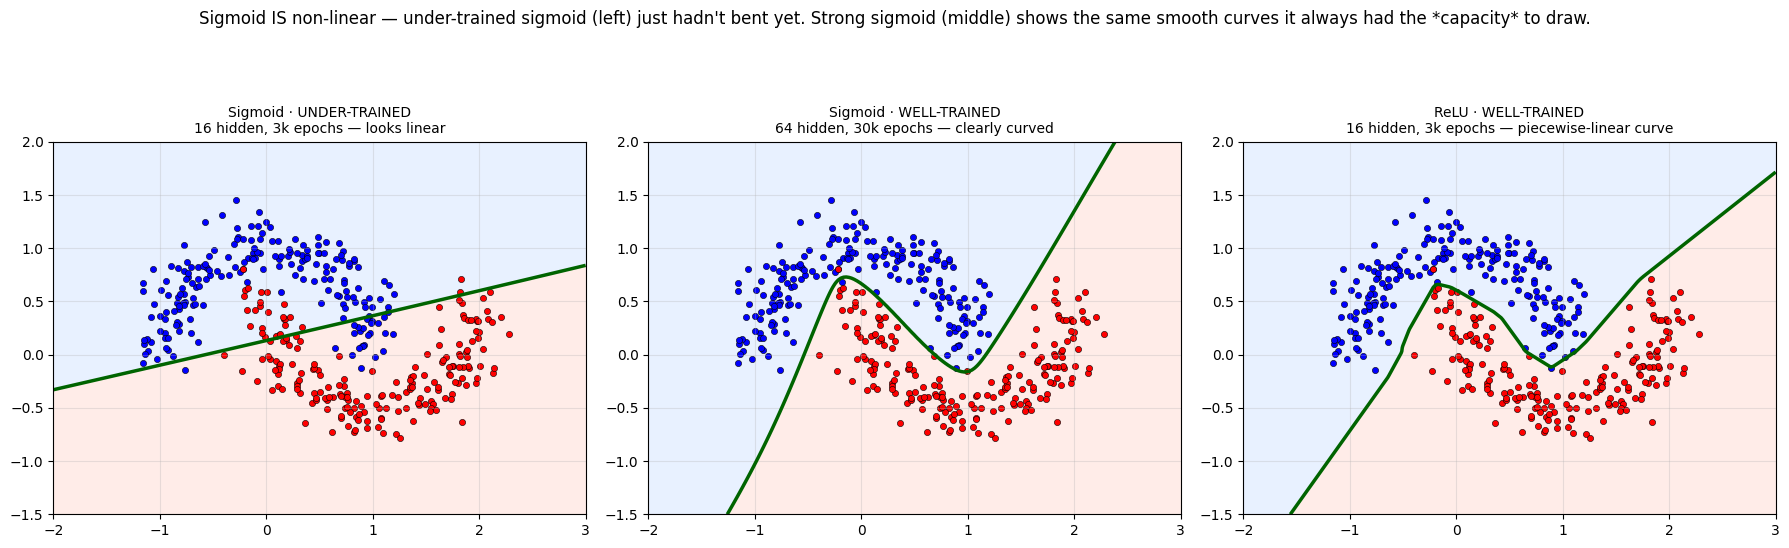

Read the three panels left to right:
  LEFT   under-trained sigmoid: nearly straight -> looks linear, but not because
         sigmoid IS linear. The vanishing gradient just never let it bend.
  MIDDLE strong sigmoid:        a smooth, genuinely curved boundary tracking both moons.
         Same activation, same dataset - only training time + capacity changed.
  RIGHT  ReLU:                  a piecewise-linear boundary (many straight segments
         glued at corners). It LOOKS curved, but it is actually a chain of straight lines.

CONCLUSION: the visual difference is about training quality and curve smoothness, NOT
about whether sigmoid is linear. (It is not.)


In [16]:
# Re-train sigmoid with MORE capacity + MORE epochs and plot all three boundaries side-by-side
sig_strong, sig_strong_losses = train('sigmoid', epochs=30_000, hidden=64, lr=0.5)

print(f'Original sigmoid (16 hidden, 3k epochs):  final BCE = {sig_losses[-1][1]:.4f}')
print(f'Strong sigmoid   (64 hidden, 30k epochs): final BCE = {sig_strong_losses[-1][1]:.4f}')
print(f'ReLU             (16 hidden, 3k epochs):  final BCE = {relu_losses[-1][1]:.4f}')
print()

fig, axes = plt.subplots(1, 3, figsize=(18, 5.8))

for ax, mlp, title, subtitle in [
    (axes[0], sig_mlp,    'Sigmoid · UNDER-TRAINED',     '16 hidden, 3k epochs — looks linear'),
    (axes[1], sig_strong, 'Sigmoid · WELL-TRAINED',      '64 hidden, 30k epochs — clearly curved'),
    (axes[2], relu_mlp,   'ReLU · WELL-TRAINED',         '16 hidden, 3k epochs — piecewise-linear curve'),
]:
    preds = mlp.forward(grid).reshape(xx.shape)
    ax.contourf(xx, yy, preds, levels=[0, 0.5, 1.0],
                colors=['#cce0ff', '#ffd6cc'], alpha=0.45)
    ax.contour(xx, yy, preds, levels=[0.5], colors='#006400', linewidths=2.5)
    ax.scatter(X[y[:,0]==0, 0], X[y[:,0]==0, 1], c='blue', s=20,
               edgecolors='black', lw=0.4)
    ax.scatter(X[y[:,0]==1, 0], X[y[:,0]==1, 1], c='red',  s=20,
               edgecolors='black', lw=0.4)
    ax.set_title(f'{title}\n{subtitle}', fontsize=10)
    ax.set_aspect('equal'); ax.grid(alpha=0.3)

fig.suptitle("Sigmoid IS non-linear — under-trained sigmoid (left) just hadn't bent yet. "
             "Strong sigmoid (middle) shows the same smooth curves it always had the *capacity* to draw.",
             fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

print('Read the three panels left to right:')
print('  LEFT   under-trained sigmoid: nearly straight -> looks linear, but not because')
print('         sigmoid IS linear. The vanishing gradient just never let it bend.')
print('  MIDDLE strong sigmoid:        a smooth, genuinely curved boundary tracking both moons.')
print('         Same activation, same dataset - only training time + capacity changed.')
print('  RIGHT  ReLU:                  a piecewise-linear boundary (many straight segments')
print('         glued at corners). It LOOKS curved, but it is actually a chain of straight lines.')
print()
print('CONCLUSION: the visual difference is about training quality and curve smoothness, NOT')
print('about whether sigmoid is linear. (It is not.)')

## 6. The dying-ReLU experiment

Initialize one hidden layer's biases to a large negative value. With ReLU, all those neurons output 0 and the derivative is 0 → they're dead. Then repeat with Leaky ReLU and watch them recover.

Plain ReLU final BCE:     0.6931471824645996
Leaky ReLU final BCE:     0.2953755259513855
Plain ReLU dead neurons:  8 out of 8
Leaky ReLU dead neurons:  0 out of 8


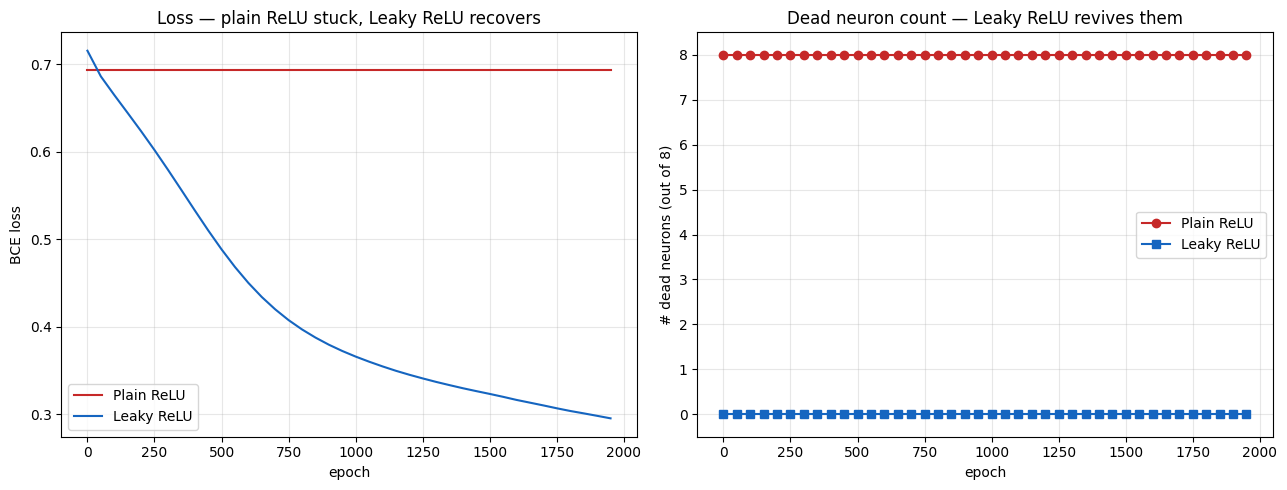

In [17]:
def dying_mlp(use_leaky=False, hidden=8, epochs=2000, lr=0.1):
    rng = np.random.default_rng(0)
    W1 = rng.normal(0, np.sqrt(2/2), (2, hidden)).astype(np.float32)
    b1 = np.full(hidden, -5.0, dtype=np.float32)   # SABOTAGE: all neurons start dead
    W2 = rng.normal(0, np.sqrt(2/hidden), (hidden, 1)).astype(np.float32)
    b2 = np.zeros(1, dtype=np.float32)

    def act(z):  return leaky_relu(z) if use_leaky else relu(z)
    def act_d(z): return leaky_relu_d(z) if use_leaky else relu_d(z)

    losses = []
    dead_counts = []
    for ep in range(epochs):
        Z1 = X @ W1 + b1; H = act(Z1)
        Z2 = H @ W2 + b2; Y = sigmoid(Z2)
        N = y.shape[0]
        dZ2 = (Y - y) / N
        dW2 = H.T @ dZ2; db2 = dZ2.sum(0)
        dH  = dZ2 @ W2.T
        dZ1 = dH * act_d(Z1)
        dW1 = X.T @ dZ1; db1 = dZ1.sum(0)
        W1 -= lr*dW1; b1 -= lr*db1; W2 -= lr*dW2; b2 -= lr*db2
        if ep % 50 == 0:
            p = np.clip(Y, 1e-7, 1-1e-7)
            losses.append((ep, float(-np.mean(y*np.log(p) + (1-y)*np.log(1-p)))))
            # Count dead neurons (output exactly 0 for every sample)
            dead_counts.append((ep, int((H == 0).all(axis=0).sum())))
    return losses, dead_counts

relu_losses_dead,  relu_dead  = dying_mlp(use_leaky=False)
leaky_losses_dead, leaky_dead = dying_mlp(use_leaky=True)

print('Plain ReLU final BCE:    ', relu_losses_dead[-1][1])
print('Leaky ReLU final BCE:    ', leaky_losses_dead[-1][1])
print('Plain ReLU dead neurons: ', relu_dead[-1][1], 'out of 8')
print('Leaky ReLU dead neurons: ', leaky_dead[-1][1], 'out of 8')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(*zip(*relu_losses_dead),  color='#c62828', label='Plain ReLU')
axes[0].plot(*zip(*leaky_losses_dead), color='#1565c0', label='Leaky ReLU')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('BCE loss')
axes[0].set_title('Loss — plain ReLU stuck, Leaky ReLU recovers')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(*zip(*relu_dead),  '-o', color='#c62828', label='Plain ReLU')
axes[1].plot(*zip(*leaky_dead), '-s', color='#1565c0', label='Leaky ReLU')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('# dead neurons (out of 8)')
axes[1].set_title('Dead neuron count — Leaky ReLU revives them')
axes[1].set_ylim(-0.5, 8.5); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## **changing the initial bias from `-5.0` to `-1.0`. How many neurons die now? Why?**

Plain ReLU final BCE:     0.2545592784881592
Leaky ReLU final BCE:     0.25533783435821533
Plain ReLU dead neurons:  4 out of 8
Leaky ReLU dead neurons:  0 out of 8


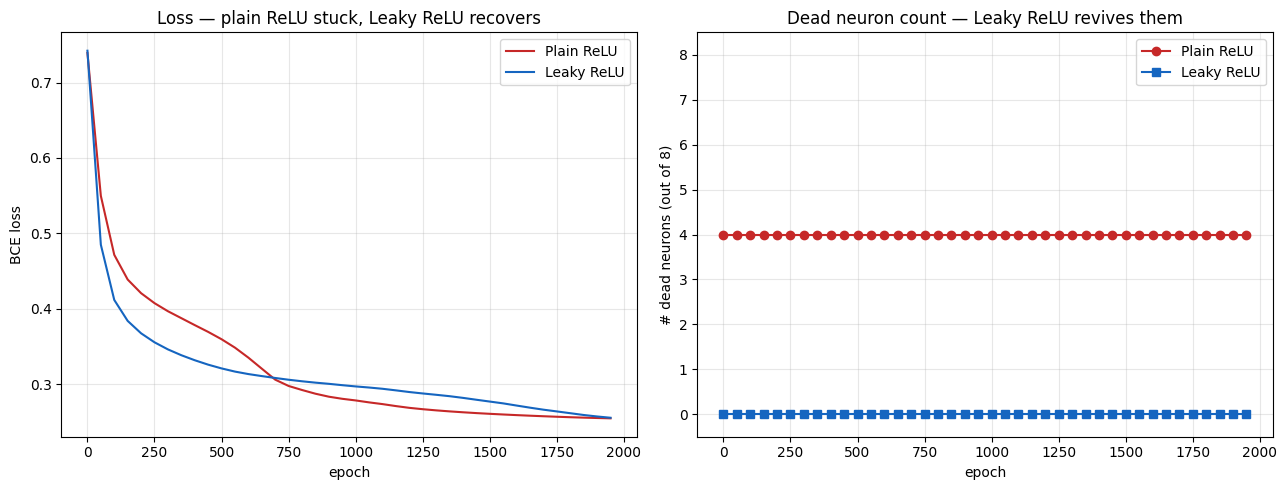

In [20]:
def dying_mlp(use_leaky=False, hidden=8, epochs=2000, lr=0.1):
    rng = np.random.default_rng(0)
    W1 = rng.normal(0, np.sqrt(2/2), (2, hidden)).astype(np.float32)
    b1 = np.full(hidden, -1.0, dtype=np.float32)   # SABOTAGE: all neurons start dead
    W2 = rng.normal(0, np.sqrt(2/hidden), (hidden, 1)).astype(np.float32)
    b2 = np.zeros(1, dtype=np.float32)

    def act(z):  return leaky_relu(z) if use_leaky else relu(z)
    def act_d(z): return leaky_relu_d(z) if use_leaky else relu_d(z)

    losses = []
    dead_counts = []
    for ep in range(epochs):
        Z1 = X @ W1 + b1; H = act(Z1)
        Z2 = H @ W2 + b2; Y = sigmoid(Z2)
        N = y.shape[0]
        dZ2 = (Y - y) / N
        dW2 = H.T @ dZ2; db2 = dZ2.sum(0)
        dH  = dZ2 @ W2.T
        dZ1 = dH * act_d(Z1)
        dW1 = X.T @ dZ1; db1 = dZ1.sum(0)
        W1 -= lr*dW1; b1 -= lr*db1; W2 -= lr*dW2; b2 -= lr*db2
        if ep % 50 == 0:
            p = np.clip(Y, 1e-7, 1-1e-7)
            losses.append((ep, float(-np.mean(y*np.log(p) + (1-y)*np.log(1-p)))))
            # Count dead neurons (output exactly 0 for every sample)
            dead_counts.append((ep, int((H == 0).all(axis=0).sum())))
    return losses, dead_counts

relu_losses_dead,  relu_dead  = dying_mlp(use_leaky=False)
leaky_losses_dead, leaky_dead = dying_mlp(use_leaky=True)

print('Plain ReLU final BCE:    ', relu_losses_dead[-1][1])
print('Leaky ReLU final BCE:    ', leaky_losses_dead[-1][1])
print('Plain ReLU dead neurons: ', relu_dead[-1][1], 'out of 8')
print('Leaky ReLU dead neurons: ', leaky_dead[-1][1], 'out of 8')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(*zip(*relu_losses_dead),  color='#c62828', label='Plain ReLU')
axes[0].plot(*zip(*leaky_losses_dead), color='#1565c0', label='Leaky ReLU')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('BCE loss')
axes[0].set_title('Loss — plain ReLU stuck, Leaky ReLU recovers')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(*zip(*relu_dead),  '-o', color='#c62828', label='Plain ReLU')
axes[1].plot(*zip(*leaky_dead), '-s', color='#1565c0', label='Leaky ReLU')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('# dead neurons (out of 8)')
axes[1].set_title('Dead neuron count — Leaky ReLU revives them')
axes[1].set_ylim(-0.5, 8.5); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

With the initial bias `b1` set to `-1.0` (instead of `-5.0`), the results show that **4 out of 8 Plain ReLU neurons died**.

**Why fewer neurons died:**

-   **Initial Bias Impact:** A bias of `-1.0` is less negative than `-5.0`. The pre-activation `Z1 = X @ W1 + b1`. A larger (less negative) bias means `Z1` is more likely to be positive for some inputs `X` and weights `W1`. If `Z1 > 0` for any input, the ReLU neuron will 'activate' and its output `H` will be greater than zero. When `H > 0`, the ReLU derivative is 1, allowing gradients to flow and the neuron to learn.
-   **Chance for Activation:** With `b1 = -5.0`, the strong negative bias pushed most (or all) `Z1` values into the negative region, causing `H` to be 0 for all inputs and thus `ReLU'(Z1)` to be 0, leading to 'death'. With `b1 = -1.0`, some `Z1` values are likely to be positive, giving those neurons a chance to become active and update their weights and biases during training.

This experiment further highlights how initialization strategies, especially for biases, can significantly impact the 'dying ReLU' problem. A less aggressively negative bias allows more neurons to start in a 'live' state.